
--- Evaluating Density Level: 1.00% ---
Density: 1.00%, Average Runtime: 0.2930 seconds

--- Evaluating Density Level: 5.00% ---
Density: 5.00%, Average Runtime: 1.5409 seconds

--- Evaluating Density Level: 10.00% ---
Density: 10.00%, Average Runtime: 3.0150 seconds

--- Evaluating Density Level: 15.00% ---
Density: 15.00%, Average Runtime: 4.3102 seconds

--- Evaluating Density Level: 20.00% ---
Density: 20.00%, Average Runtime: 5.6972 seconds

--- Evaluating Density Level: 25.00% ---
Density: 25.00%, Average Runtime: 6.6872 seconds

--- Evaluating Density Level: 30.00% ---
Density: 30.00%, Average Runtime: 7.6136 seconds

--- Evaluating Density Level: 35.00% ---
Density: 35.00%, Average Runtime: 9.0760 seconds

--- Evaluating Density Level: 40.00% ---
Density: 40.00%, Average Runtime: 10.2889 seconds

--- Evaluating Density Level: 45.00% ---
Density: 45.00%, Average Runtime: 11.2730 seconds

--- Evaluating Density Level: 50.00% ---
Density: 50.00%, Average Runtime: 11.8829 seconds


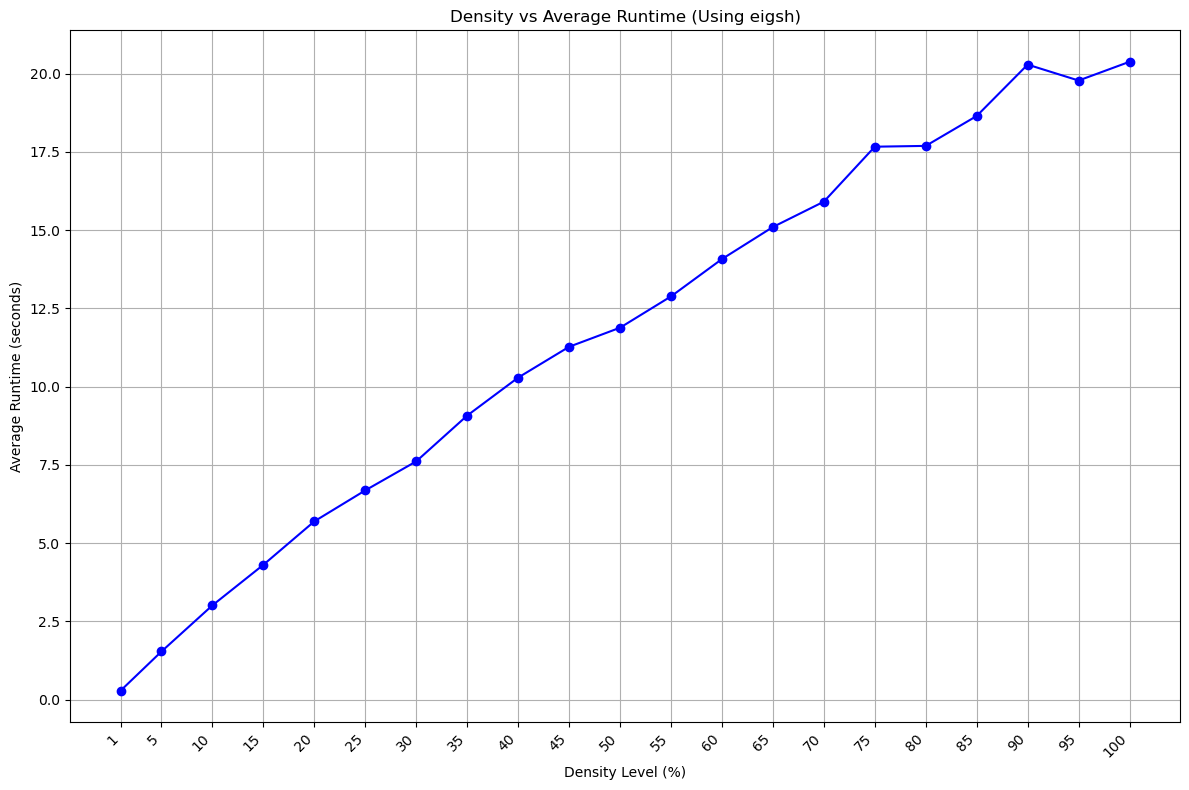

In [1]:
import numpy as np
from scipy.sparse import random as sparse_random
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import time

def generate_sparse_matrix(size, density):
    diagonal_values = np.linspace(-1, 1, size)
    rvs = np.random.randn
    upper = sparse_random(size, size, density=density / 2, data_rvs=rvs, format='coo')
    matrix_s = upper + upper.T
    matrix_s.setdiag(diagonal_values)
    
    #print(f"Generated matrix of size {size} with density {density}.")
    return matrix_s.tocsr()

def evaluate_average_iterations(size, density_levels, num_trials=40, tol=1e-08):
    avg_runtime_per_density = []

    for density in density_levels:
        print(f"\n--- Evaluating Density Level: {density*100:.2f}% ---")
        total_runtime = 0

        for trial in range(num_trials):
            #print(f"Trial {trial + 1} for density {density}...")
            matrix_s = generate_sparse_matrix(size, density)

            # Time the eigsh function
            start_time = time.time()
            eigsh(matrix_s, k=1, which='SA', tol=0, return_eigenvectors=False)
            runtime = time.time() - start_time
            #print(f"Trial {trial + 1}: Runtime = {runtime:.4f} seconds")
            total_runtime += runtime

        avg_runtime = total_runtime / num_trials
        avg_runtime_per_density.append(avg_runtime)
        print(f"Density: {density*100:.2f}%, Average Runtime: {avg_runtime:.4f} seconds")

    return avg_runtime_per_density

# Parameters
size = 10000
density_levels = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

# Evaluate the runtime for different sparsity levels
average_runtimes = evaluate_average_iterations(size, density_levels, num_trials=40, tol=1e-8)

# Plot the results
plt.figure(figsize=(12, 8))
plt.plot([d * 100 for d in density_levels], average_runtimes, marker='o', linestyle='-', color='b')
plt.xlabel('Density Level (%)')
plt.ylabel('Average Runtime (seconds)')
plt.title('Density vs Average Runtime (Using eigsh)')
plt.grid(True)
plt.xticks([d * 100 for d in density_levels], rotation=45, ha="right")
plt.tight_layout()
plt.show()
